# Task 1: Dataset Understanding

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', 200)

In [3]:
# Load dataset from Google Drive

dataset_path = "/content/drive/MyDrive/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"

df = pd.read_csv(dataset_path)

# Display first 5 rows
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I appreciate the quick response.,positive,12,0
3,TKT00004,social,My refund is still pending and this experience is frustrating. My ticket number is 33927.,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# Display dataset information

print("Dataset Shape:", df.shape)
print("\nDataset Columns:\n")
print(df.columns)

print("\nDataset Info:\n")
df.info()

Dataset Shape: (1500, 6)

Dataset Columns:

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB


In [5]:
# Total number of records

total_records = len(df)

print("Total Number of Records:", total_records)

Total Number of Records: 1500


In [6]:
# Display unique sentiment labels

labels = df['sentiment_label'].unique()

print("Target Labels / Classes:")
print(labels)

Target Labels / Classes:
['neutral' 'positive' 'negative']


In [7]:
# Display sample customer messages

print("Sample Customer Messages:\n")

for i in range(5):
    print(f"Message {i+1}:")
    print(df['customer_message'].iloc[i])
    print("-" * 80)

Sample Customer Messages:

Message 1:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
--------------------------------------------------------------------------------
Message 2:
I need information about the payment process.
--------------------------------------------------------------------------------
Message 3:
The refund process was fast and convenient. I appreciate the quick response.
--------------------------------------------------------------------------------
Message 4:
My refund is still pending and this experience is frustrating. My ticket number is 33927.
--------------------------------------------------------------------------------
Message 5:
Please tell me how to update my account details.
--------------------------------------------------------------------------------


In [8]:
# Calculate text length statistics

df['text_length'] = df['customer_message'].astype(str).apply(len)

average_length = df['text_length'].mean()

print("Average Text Length:", round(average_length, 2))

print("\nText Length Statistics:\n")
print(df['text_length'].describe())

Average Text Length: 72.76

Text Length Statistics:

count    1500.000000
mean       72.756667
std        21.026496
min        42.000000
25%        54.000000
50%        70.000000
75%        88.000000
max       143.000000
Name: text_length, dtype: float64


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


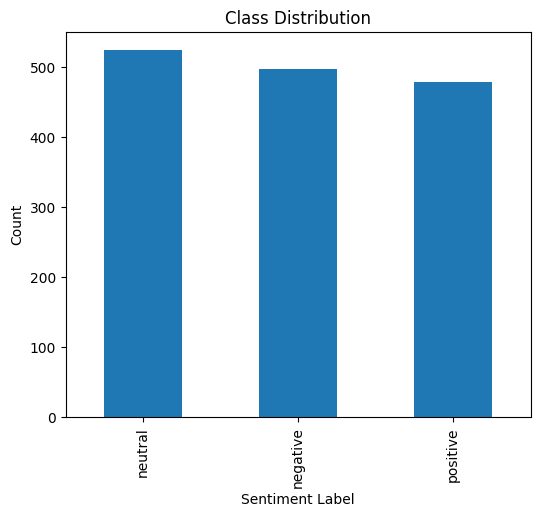

In [10]:
import os

os.makedirs("results", exist_ok=True)

# Plot class distribution

class_counts = df['sentiment_label'].value_counts()

print(class_counts)

# Create figure
plt.figure(figsize=(6, 5))

# Plot bar chart
class_counts.plot(kind='bar')

# Labels and title
plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

# Save figure
plt.savefig("results/model_evaluation.png", bbox_inches='tight')

# Show plot
plt.show()

# Task 2: Text Preprocessing

In [11]:
# Import NLP libraries

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [16]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
# Load English stopwords

stop_words = set(stopwords.words('english'))

print("Number of Stopwords:", len(stop_words))

Number of Stopwords: 198


In [18]:
# Function for text preprocessing

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens back into text
    cleaned_text = " ".join(filtered_tokens)

    return cleaned_text

In [19]:
# Apply preprocessing to customer messages

df['cleaned_message'] = df['customer_message'].apply(clean_text)

# Display sample cleaned messages

df[['customer_message', 'cleaned_message']].head()

,customer_message,cleaned_message
0,I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.,need information payment process ticket number please respond soon possible
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I appreciate the quick response.,refund process fast convenient appreciate quick response
3,My refund is still pending and this experience is frustrating. My ticket number is 33927.,refund still pending experience frustrating ticket number
4,Please tell me how to update my account details.,please tell update account details


In [20]:
# Display sample preprocessing results

for i in range(3):

    print(f"\nOriginal Text {i+1}:")
    print(df['customer_message'].iloc[i])

    print(f"\nCleaned Text {i+1}:")
    print(df['cleaned_message'].iloc[i])

    print("\n" + "-" * 100)


Original Text 1:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Cleaned Text 1:
need information payment process ticket number please respond soon possible

----------------------------------------------------------------------------------------------------

Original Text 2:
I need information about the payment process.

Cleaned Text 2:
need information payment process

----------------------------------------------------------------------------------------------------

Original Text 3:
The refund process was fast and convenient. I appreciate the quick response.

Cleaned Text 3:
refund process fast convenient appreciate quick response

----------------------------------------------------------------------------------------------------


In [21]:
# Define tokenizer

tokenizer = Tokenizer()

# Fit tokenizer on cleaned text
tokenizer.fit_on_texts(df['cleaned_message'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

# Display sample sequence

print("Sample Sequence:\n")
print(sequences[0])

Sample Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]


In [22]:
# Calculate vocabulary size

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 147


In [23]:
# Define maximum sequence length

max_length = 50

# Apply padding

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Display shape

print("Padded Sequence Shape:", padded_sequences.shape)

# Display sample padded sequence

print("\nSample Padded Sequence:\n")
print(padded_sequences[0])

Padded Sequence Shape: (1500, 50)

Sample Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [24]:
# Analyze sequence lengths

sequence_lengths = [len(seq) for seq in sequences]

print("Average Sequence Length:",
      np.mean(sequence_lengths))

print("Maximum Sequence Length:",
      np.max(sequence_lengths))

print("Minimum Sequence Length:",
      np.min(sequence_lengths))

Average Sequence Length: 6.63
Maximum Sequence Length: 13
Minimum Sequence Length: 4
